# Relevant Segment Extraction（RSE）：把“碎片命中”还原成“连续段落”

本节目标：实现 RSE 的最小版本，理解它为什么能显著提升 RAG 的回答质量。

## 核心直觉

我们把文档切成 chunks 后检索：

- **chunk 切得小**：命中更精准，但上下文容易不完整
- **chunk 切得大**：上下文更完整，但检索更难精确定位

现实中同一个系统会同时遇到两类问题：

- 有些问题只需要一句话（小 chunk 就够）
- 有些问题需要一整段连续表格/整节说明（需要大段上下文）

RSE 的关键洞见是：

> **相关 chunks 往往在原文中是“成簇聚集”的**。

因此，在“向量检索（可选 rerank）之后、把上下文交给 LLM 之前”，我们可以：

1. 先得到每个 chunk 的相关性分数（或 rank + 分数）
2. 在原文 chunk 序列上寻找“高分簇”的**连续区间（segment）**
3. 把这些区间按原文顺序拼回去，作为更完整的上下文

这样能同时获得：

- **更完整**：把夹在高相关 chunk 中间的“漏标 chunk”补回来
- **更连贯**：上下文按原文顺序呈现，LLM 更好理解

> 原仓库用 Cohere reranker 为每个 chunk 打分；为了在现有环境更容易跑通，这里用 **OpenAI embeddings 的 cosine similarity** 生成 chunk 相关性分数，演示同样的 RSE 过程。

## 0) 导入依赖并加载环境变量

延续前面 notebook 的约定：从 `../.env` 读取 `OPENAI_API_KEY`。

这节会画相关性分布图：需要 `matplotlib`。如果环境里没有它，这一格会直接报错提醒安装。

In [1]:
from __future__ import annotations

import importlib.util
from pathlib import Path
from typing import List, Tuple

import numpy as np
import requests
from dotenv import load_dotenv

load_dotenv("../.env")

assert importlib.util.find_spec("matplotlib") is not None, "缺少依赖：matplotlib（请先安装后再运行）"
import matplotlib.pyplot as plt

from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

## 1) 准备示例文档并切 chunks（无 overlap，方便拼回连续段）

原仓库用 `nike_2023_annual_report.txt` 演示。这里沿用同一份文本，并按固定 `chunk_size=800` 切成不重叠 chunks。

RSE 有一个很关键的工程要求：

- **chunk 必须无 overlap**（`chunk_overlap=0`），这样我们才能用 `(doc_id, chunk_index)` 把连续区间拼回原文。

In [2]:
import os
os.environ["HTTP_PROXY"] = "http://127.0.0.1:7890"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"
os.environ["ALL_PROXY"] = "http://127.0.0.1:7890"

In [3]:
def split_into_chunks(text: str, *, chunk_size: int = 800) -> List[str]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=0,
        length_function=len,
    )
    docs = splitter.create_documents([text])
    return [d.page_content for d in docs]


DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

NIKE_URL = "https://raw.githubusercontent.com/NirDiamant/RAG_Techniques/main/data/nike_2023_annual_report.txt"
NIKE_PATH = DATA_DIR / "nike_2023_annual_report.txt"

if not NIKE_PATH.exists():
    resp = requests.get(NIKE_URL, timeout=60)
    resp.raise_for_status()
    NIKE_PATH.write_bytes(resp.content)

text = NIKE_PATH.read_text(encoding="utf-8", errors="ignore")
chunks = split_into_chunks(text, chunk_size=800)

print(f"Split the document into {len(chunks)} chunks")

Split the document into 500 chunks


## 2) 为每个 chunk 计算相关性分数，并可视化“相关性在文档中的分布”

原仓库的演示 query 是：`Nike consolidated financial statements`，它通常需要**连续多块**才能完整回答。

为了更贴近原仓库的“rank + 分数融合”的稳定性，这里也做两步融合：

- 先计算 query 与每个 chunk 的 cosine similarity（基于 embeddings）
- 再按相似度排序，用指数衰减把“排名信息”融合进 chunk value

最终我们会画出：

- x 轴：chunk_index（原文顺序）
- y 轴：chunk_value（融合后的相关性强度）

In [4]:
def cosine_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Return cosine similarity for each row in `a` vs vector `b`."""
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-12)
    b_norm = b / (np.linalg.norm(b) + 1e-12)
    return a_norm @ b_norm


def transform(x01: np.ndarray) -> np.ndarray:
    """把 0-1 区间的分数拉开一些差距（类似原仓库的 beta 变换动机）。"""
    x01 = np.clip(x01, 0.0, 1.0)
    return np.sqrt(x01)


def score_chunks(
    query: str,
    chunks: List[str],
    *,
    embedding_model: OpenAIEmbeddings,
    decay_rate: float = 30.0,
) -> Tuple[List[float], List[float]]:
    """返回 (similarity_scores, chunk_values)（都按原文 chunk 顺序对齐）。"""
    chunk_vecs = np.array(embedding_model.embed_documents(chunks), dtype=np.float32)
    q_vec = np.array(embedding_model.embed_query(query), dtype=np.float32)

    cos = cosine_similarity_matrix(chunk_vecs, q_vec)

    # 规范化到 0-1（方便后续 penalty 思路）
    sim01 = (cos + 1.0) / 2.0
    sim01 = transform(sim01)

    order = np.argsort(-sim01)  # rank: high -> low

    similarity_scores = np.zeros(len(chunks), dtype=np.float32)
    chunk_values = np.zeros(len(chunks), dtype=np.float32)

    for rank, idx in enumerate(order.tolist()):
        s = float(sim01[idx])
        similarity_scores[idx] = s
        chunk_values[idx] = float(np.exp(-rank / decay_rate) * s)

    return similarity_scores.tolist(), chunk_values.tolist()


def plot_relevance_scores(
    chunk_values: List[float],
    start_index: int | None = None,
    end_index: int | None = None,
) -> None:
    if start_index is None:
        start_index = 0
    if end_index is None:
        end_index = len(chunk_values)

    xs = np.arange(start_index, end_index)
    ys = np.asarray(chunk_values[start_index:end_index], dtype=np.float32)

    plt.figure(figsize=(12, 5))
    plt.title("Similarity of each chunk in the document to the search query")
    plt.ylim(0, 1)
    plt.xlabel("Chunk index")
    plt.ylabel("Query-chunk similarity")
    plt.scatter(xs, ys, s=12)
    plt.show()

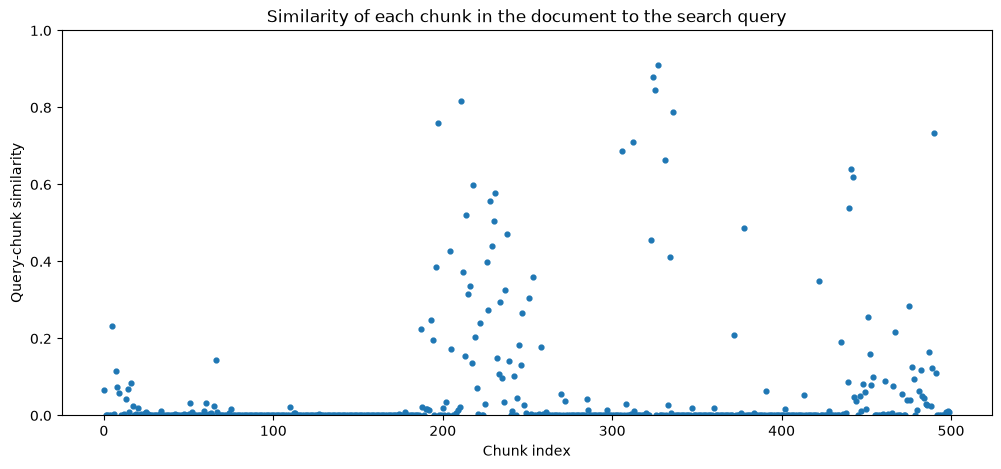

In [5]:
query = "Nike consolidated financial statements"

emb = OpenAIEmbeddings(model="text-embedding-3-small")
similarity_scores, chunk_values = score_chunks(query, chunks, embedding_model=emb)

plot_relevance_scores(chunk_values)

### 如何读上面的相关性分布图

- **x 轴**：chunk index（文档从头到尾的顺序）
- **y 轴**：这个 chunk 对 query 的“相关性强度”（这里融合了相似度与 rank）

你会看到：高相关的点通常不是零散分布，而是会集中在某几个区间——这就是 RSE 依赖的“相关 chunks 成簇聚集”。

接下来我们放大其中一个簇来观察。

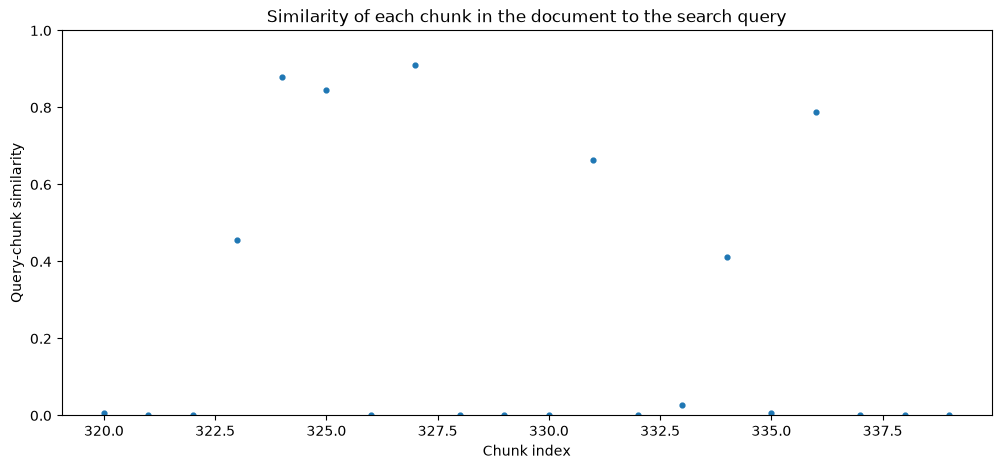

In [6]:
plot_relevance_scores(chunk_values, 320, 340)

## 3) 观察这个区间到底是什么内容（连续段的价值）

原仓库在 320-340 这一段观察到：

- 单看“被标为相关”的 chunks，往往是断断续续的
- 但事实上，中间夹着的 chunk 很可能也是同一张表 / 同一节内容的一部分

我们直接把这个范围的 chunk 文本打印出来，看看它们是不是属于同一个连续段落（例如财务报表）。

In [7]:
def print_document_segment(chunks: List[str], start_index: int, end_index: int) -> None:
    for i in range(start_index, end_index):
        print(f"\nChunk {i}")
        print(chunks[i])


print_document_segment(chunks, 320, 340)


Chunk 320
financial statements, taken as a whole, and we are not, by communicating the critical audit matter below , providing a separate 
opinion on the critical audit matter or on the accounts or disclosures to which it relates.
Accounting for Income Taxes
As described in Notes 1 and 7 to the consolidated financial statements, the Company recorded income tax expense of $1,131 
million for the year ended May 31, 2023, and has net deferred tax assets of $1,799 million, including a valuation allowance of $22 
million, and total gross unrecognized tax benefits, excluding related interest and penalties, of $936 million as of May 31, 2023, 
$651 million of which would affect the Company's effective tax rate if recognized in future periods. The realization of deferred tax

Chunk 321
assets is dependent on future taxable earnings. Management assesses the scheduled reversal of deferred tax liabilities, 
projected future taxable income and available tax planning strategies and considers forei

如果你看到类似 `Consolidated Statement ...` 这样的标题在某个 chunk 开始出现，并且后续连续多个 chunk 都是财务报表内容，那么就说明：

- **这个问题需要的是一个连续 segment**，而不是几个零散 chunk
- 即使有些 chunk 的分数没那么高，它们也可能是这张表/这一节不可或缺的一部分

这正是 RSE 要解决的问题。

## 4) 从“相关性分数”自动找出最佳 segments

我们希望把问题改写成一个可优化的形式：

- chunk 的分数越高越好
- chunk 的分数太低（不相关）就应该“扣分”

做法是：

1. 给每个 chunk value 减去一个常数 `irrelevant_chunk_penalty`（例如 0.2）
2. 这样：
   - 原本不相关的 chunk 会变成负值
   - 原本相关的 chunk 仍保持正值
3. 定义 segment 的分数为该区间内 chunk values 的**和**

于是“找最佳 segments”就变成了一个带约束的 **maximum sum subarray** 问题。

下面的实现是为了教学而写的简化版本：

- 限制单个 segment 的最大长度 `max_length`
- 限制所有 segments 的总长度 `overall_max_length`
- 要求 segment 得分至少 `minimum_value` 才保留

In [8]:
def get_best_segments(
    relevance_values: List[float],
    *,
    max_length: int,
    overall_max_length: int,
    minimum_value: float,
) -> Tuple[List[Tuple[int, int]], List[float]]:
    """教学版：暴力 + 约束，找分数最高且互不重叠的 segments。"""

    best_segments: List[Tuple[int, int]] = []
    scores: List[float] = []
    total_length = 0

    while total_length < overall_max_length:
        best_segment: Tuple[int, int] | None = None
        best_value = -1e9

        for start in range(len(relevance_values)):
            if relevance_values[start] < 0:
                continue

            end_upper = min(start + max_length + 1, len(relevance_values) + 1)
            for end in range(start + 1, end_upper):
                if relevance_values[end - 1] < 0:
                    continue

                # 跳过与已选 segment 重叠的候选
                if any(start < seg_end and end > seg_start for seg_start, seg_end in best_segments):
                    continue

                # 控制总长度预算
                if total_length + (end - start) > overall_max_length:
                    continue

                value = sum(relevance_values[start:end])
                if value > best_value:
                    best_value = value
                    best_segment = (start, end)

        if best_segment is None or best_value < minimum_value:
            break

        best_segments.append(best_segment)
        scores.append(float(best_value))
        total_length += best_segment[1] - best_segment[0]

    return best_segments, scores

In [9]:
# 约束参数（与原仓库含义保持一致）
irrelevant_chunk_penalty = 0.2
max_length = 20
overall_max_length = 30
minimum_value = 0.7

relevance_values = [v - irrelevant_chunk_penalty for v in chunk_values]

best_segments, scores = get_best_segments(
    relevance_values,
    max_length=max_length,
    overall_max_length=overall_max_length,
    minimum_value=minimum_value,
)

print("Best segment indices")
print(best_segments)
print()
print("Best segment scores")
print(scores)
print()

Best segment indices
[(323, 337), (211, 220), (226, 232)]

Best segment scores
[2.192395360306546, 1.6548767805099487, 1.554157096147537]



## 5) 把 segments 拼回“连续上下文”，再交给 LLM

RSE 真正想要的输出，是一个或多个**连续文本段**：

- 每个 segment 由原文连续 chunks 拼接而成
- 多个 segment 之间互不重叠
- 总长度受控（不会无限膨胀）

下面我们把找到的 segments 拼回文本，看看第一个段落长什么样。

In [10]:
segments_text: List[str] = []
for start, end in best_segments:
    segments_text.append("\n".join(chunks[start:end]))

print(f"Num segments: {len(segments_text)}")
if segments_text:
    print("\n--- Segment 1 (preview) ---\n")
    print(segments_text[0][:2000])

Num segments: 3

--- Segment 1 (preview) ---

income taxes, evaluating changes in and compliance with tax laws, and testing the calculation of the provision of income taxes. 
Professionals with specialized skill and knowledge were used to assist in evaluating changes in and compliance with the tax laws 
and regulations and the provision for income taxes.
/s/ PricewaterhouseCoopers LLP
Portland, Oregon
July 20, 2023 
We have served as the Company's auditor since 1974. 
NIKE, INC.      54NIKE, INC.
CONSOLIDATED STATEMENTS OF INCOME
YEAR ENDED MAY 31,
(In millions, except per share data) 2023 2022 2021
Revenues $ 51,217 $ 46,710 $ 44,538 
Cost of sales  28,925  25,231  24,576 
Gross profit  22,292  21,479  19,962 
Demand creation expense  4,060  3,850  3,114 
Operating overhead expense  12,317  10,954  9,911
Total selling and administrative expense  16,377  14,804  13,025 
Interest expense (income), net  (6)  205  262 
Other (income) expense, net  (280)  (181)  14 
Income before income ta

## 6) 小结

- **RSE 的位置**：向量检索（可选 rerank）之后、把上下文交给 LLM 之前
- **RSE 的输出**：一组连续 segments（原文顺序、互不重叠、长度预算受控）
- **RSE 解决的问题**：把“碎片命中”的 top-k chunks 还原为“连续上下文”，并补回夹在中间的重要 chunk

原仓库还展示了在 KITE / FinanceBench 等评测上的显著收益；你可以把它理解为一种非常实用的“上下文重建”技巧，常与 CCH 联合使用。